## <Center> Temperature

CREATING TEMPERATURE TREND GRAPHS (Tmax, Tmin, Tmean)

Data loaded: 10592 records
Period: 1995-01-01 to 2023-12-31

Basin-wide parameters calculated
  Annual Tmax range: 3.71 - 6.32°C
  Annual Tmin range: -5.31 - -0.47°C
  Annual Tmean range: -0.70 - 2.51°C

✓ Trend graphs saved to: D:\GDM Model\Thesis\Results\Mann Kendall Trend\Temperature_Trend_Graphs.png


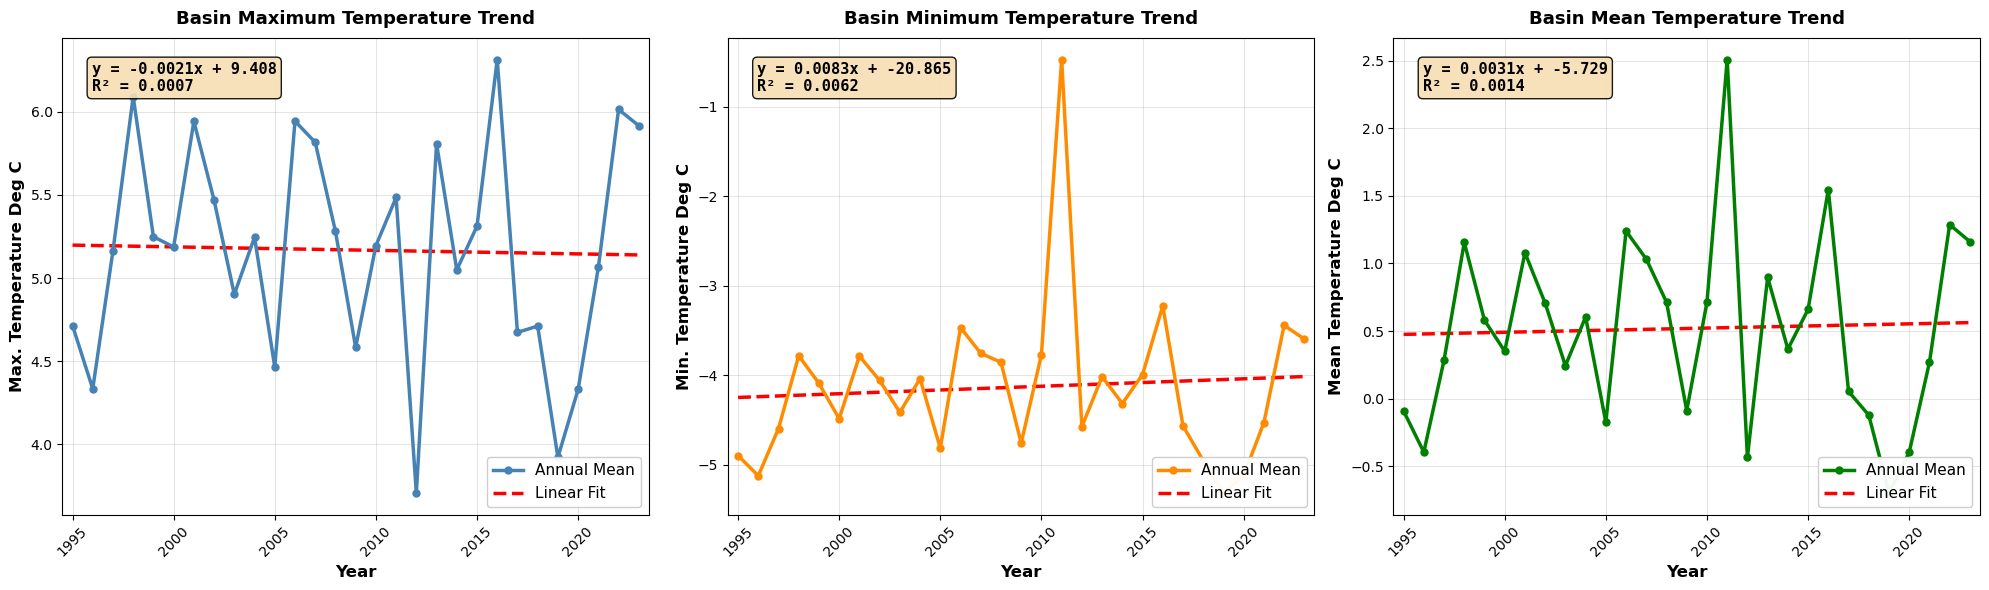


TEMPERATURE TREND STATISTICS (1995-2023)

Basin Tmax:
  Equation:          y = -0.002110x + 9.408
  R² (goodness):     0.0007
  Slope (°C/year):   -0.0021
  Total Change:      -0.06°C (over 28 years)
  p-value:           0.889495
  Significant:       No ✗

Basin Tmin:
  Equation:          y = 0.008330x + -20.865
  R² (goodness):     0.0062
  Slope (°C/year):   +0.0083
  Total Change:      +0.23°C (over 28 years)
  p-value:           0.683606
  Significant:       No ✗

Basin Tmean:
  Equation:          y = 0.003110x + -5.729
  R² (goodness):     0.0014
  Slope (°C/year):   +0.0031
  Total Change:      +0.09°C (over 28 years)
  p-value:           0.846772
  Significant:       No ✗

✓ Statistics saved to: D:\GDM Model\Thesis\Results\Mann Kendall Trend\Temperature_Trend_Statistics.xlsx


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# ════════════════════════════════════════════
# LOAD DATA
# ════════════════════════════════════════════

print("="*80)
print("CREATING TEMPERATURE TREND GRAPHS (Tmax, Tmin, Tmean)")
print("="*80 + "\n")

# Load Excel file
excel_file = r"D:\GDM Model\Thesis\Results\Mann Kendall Trend\Temperature.xlsx"

try:
    df = pd.read_excel(excel_file)
except Exception as e:
    print(f"Error reading file: {e}")
    exit()

# Convert all column names to strings
df.columns = df.columns.astype(str).str.strip()

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')
df = df.dropna(subset=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"Data loaded: {len(df)} records")
print(f"Period: {df['Date'].min().date()} to {df['Date'].max().date()}\n")

# ════════════════════════════════════════════
# CALCULATE BASIN-WIDE MEANS
# ════════════════════════════════════════════

tmax_gilgit = 'Tmax (Gilgit)'
tmin_gilgit = 'Tmin (Gilgit)'
tmax_khujreeb = 'Tmax (Khujreeb)'
tmin_khunjreeb = 'Tmin (Khunjreeb)'

# Calculate basin-wide means
df['Basin_Tmax'] = (df[tmax_gilgit] + df[tmax_khujreeb]) / 2
df['Basin_Tmin'] = (df[tmin_gilgit] + df[tmin_khunjreeb]) / 2
df['Basin_Tmean'] = (df['Basin_Tmax'] + df['Basin_Tmin']) / 2

df['Year'] = df['Date'].dt.year

# Calculate annual means
annual_tmax = df.groupby('Year')['Basin_Tmax'].mean()
annual_tmin = df.groupby('Year')['Basin_Tmin'].mean()
annual_tmean = df.groupby('Year')['Basin_Tmean'].mean()

print("Basin-wide parameters calculated")
print(f"  Annual Tmax range: {annual_tmax.min():.2f} - {annual_tmax.max():.2f}°C")
print(f"  Annual Tmin range: {annual_tmin.min():.2f} - {annual_tmin.max():.2f}°C")
print(f"  Annual Tmean range: {annual_tmean.min():.2f} - {annual_tmean.max():.2f}°C\n")

# ════════════════════════════════════════════
# CREATE TREND GRAPH (1x3 LAYOUT)
# ════════════════════════════════════════════

fig = plt.figure(figsize=(20, 6))
fig.patch.set_facecolor('white')

years = annual_tmax.index.values

# ─────────────────────────────────────────────
# Plot 1: Basin Tmax
# ─────────────────────────────────────────────
ax1 = plt.subplot(1, 3, 1)
values = annual_tmax.values

# Plot line
ax1.plot(years, values, linewidth=2.5, color='steelblue', marker='o', markersize=5, label='Annual Mean', zorder=3)

# Calculate linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(years, values)
r_squared = r_value ** 2

# Plot trend line
trend_line = slope * years + intercept
ax1.plot(years, trend_line, '--', linewidth=2.5, color='red', label='Linear Fit', zorder=2)

# Add equation and R²
equation_text = f'y = {slope:.4f}x + {intercept:.3f}\nR² = {r_squared:.4f}'
ax1.text(0.05, 0.95, equation_text, transform=ax1.transAxes, 
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9),
         fontweight='bold', family='monospace')

ax1.set_xlabel('Year', fontweight='bold', fontsize=12)
ax1.set_ylabel('Max. Temperature Deg C', fontweight='bold', fontsize=12)
ax1.set_title('Basin Maximum Temperature Trend', fontweight='bold', fontsize=13, pad=10)
ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, color='gray')
ax1.legend(loc='lower right', fontsize=11, framealpha=0.95)
ax1.set_xlim(years.min()-0.5, years.max()+0.5)

# Format x-axis
ax1.set_xticks(range(int(years.min()), int(years.max())+1, 5))
ax1.set_xticklabels([str(y) for y in range(int(years.min()), int(years.max())+1, 5)], fontsize=10, rotation=45)

# ─────────────────────────────────────────────
# Plot 2: Basin Tmin
# ─────────────────────────────────────────────
ax2 = plt.subplot(1, 3, 2)
values = annual_tmin.values

# Plot line
ax2.plot(years, values, linewidth=2.5, color='darkorange', marker='o', markersize=5, label='Annual Mean', zorder=3)

# Calculate linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(years, values)
r_squared = r_value ** 2

# Plot trend line
trend_line = slope * years + intercept
ax2.plot(years, trend_line, '--', linewidth=2.5, color='red', label='Linear Fit', zorder=2)

# Add equation and R²
equation_text = f'y = {slope:.4f}x + {intercept:.3f}\nR² = {r_squared:.4f}'
ax2.text(0.05, 0.95, equation_text, transform=ax2.transAxes, 
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9),
         fontweight='bold', family='monospace')

ax2.set_xlabel('Year', fontweight='bold', fontsize=12)
ax2.set_ylabel('Min. Temperature Deg C', fontweight='bold', fontsize=12)
ax2.set_title('Basin Minimum Temperature Trend', fontweight='bold', fontsize=13, pad=10)
ax2.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, color='gray')
ax2.legend(loc='lower right', fontsize=11, framealpha=0.95)
ax2.set_xlim(years.min()-0.5, years.max()+0.5)

# Format x-axis
ax2.set_xticks(range(int(years.min()), int(years.max())+1, 5))
ax2.set_xticklabels([str(y) for y in range(int(years.min()), int(years.max())+1, 5)], fontsize=10, rotation=45)

# ─────────────────────────────────────────────
# Plot 3: Basin Tmean
# ─────────────────────────────────────────────
ax3 = plt.subplot(1, 3, 3)
values = annual_tmean.values

# Plot line
ax3.plot(years, values, linewidth=2.5, color='green', marker='o', markersize=5, label='Annual Mean', zorder=3)

# Calculate linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(years, values)
r_squared = r_value ** 2

# Plot trend line
trend_line = slope * years + intercept
ax3.plot(years, trend_line, '--', linewidth=2.5, color='red', label='Linear Fit', zorder=2)

# Add equation and R²
equation_text = f'y = {slope:.4f}x + {intercept:.3f}\nR² = {r_squared:.4f}'
ax3.text(0.05, 0.95, equation_text, transform=ax3.transAxes, 
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9),
         fontweight='bold', family='monospace')

ax3.set_xlabel('Year', fontweight='bold', fontsize=12)
ax3.set_ylabel('Mean Temperature Deg C', fontweight='bold', fontsize=12)
ax3.set_title('Basin Mean Temperature Trend', fontweight='bold', fontsize=13, pad=10)
ax3.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, color='gray')
ax3.legend(loc='lower right', fontsize=11, framealpha=0.95)
ax3.set_xlim(years.min()-0.5, years.max()+0.5)

# Format x-axis
ax3.set_xticks(range(int(years.min()), int(years.max())+1, 5))
ax3.set_xticklabels([str(y) for y in range(int(years.min()), int(years.max())+1, 5)], fontsize=10, rotation=45)

plt.tight_layout()
plot_path = r'D:\GDM Model\Thesis\Results\Mann Kendall Trend\Temperature_Trend_Graphs.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Trend graphs saved to: {plot_path}")
plt.show()

# ════════════════════════════════════════════
# PRINT TREND STATISTICS
# ════════════════════════════════════════════

print("\n" + "="*80)
print("TEMPERATURE TREND STATISTICS (1995-2023)")
print("="*80 + "\n")

results = []

for name, data in [('Basin Tmax', annual_tmax), ('Basin Tmin', annual_tmin), ('Basin Tmean', annual_tmean)]:
    slope, intercept, r_value, p_value, std_err = stats.linregress(years, data.values)
    r_squared = r_value ** 2
    annual_change = slope
    total_change = slope * (years[-1] - years[0])
    
    print(f"{name}:")
    print(f"  Equation:          y = {slope:.6f}x + {intercept:.3f}")
    print(f"  R² (goodness):     {r_squared:.4f}")
    print(f"  Slope (°C/year):   {annual_change:+.4f}")
    print(f"  Total Change:      {total_change:+.2f}°C (over {years[-1] - years[0]} years)")
    print(f"  p-value:           {p_value:.6f}")
    print(f"  Significant:       {'Yes ✓' if p_value < 0.05 else 'No ✗'}\n")
    
    results.append({
        'Parameter': name,
        'Equation': f'y = {slope:.6f}x + {intercept:.3f}',
        'R²': f'{r_squared:.4f}',
        'Slope (°C/year)': f'{annual_change:+.4f}',
        'Total Change (°C)': f'{total_change:+.2f}',
        'p-value': f'{p_value:.6f}',
        'Significant': 'Yes ✓' if p_value < 0.05 else 'No ✗'
    })

# Save results to Excel
results_df = pd.DataFrame(results)
results_path = r'D:\GDM Model\Thesis\Results\Mann Kendall Trend\Temperature_Trend_Statistics.xlsx'
results_df.to_excel(results_path, index=False)
print(f"✓ Statistics saved to: {results_path}")

print("="*80)

CREATING TEMPERATURE TREND GRAPHS (Tmax, Tmin, Tmean)

Data loaded: 10592 records
Period: 1995-01-01 to 2023-12-31

Basin-wide parameters calculated
  Annual Tmax range: 3.71 - 6.32°C
  Annual Tmin range: -5.31 - -0.47°C
  Annual Tmean range: -0.70 - 2.51°C

✓ Trend graphs saved to: D:\GDM Model\Thesis\Results\Mann Kendall Trend\Temperature_Trend_Graphs.png


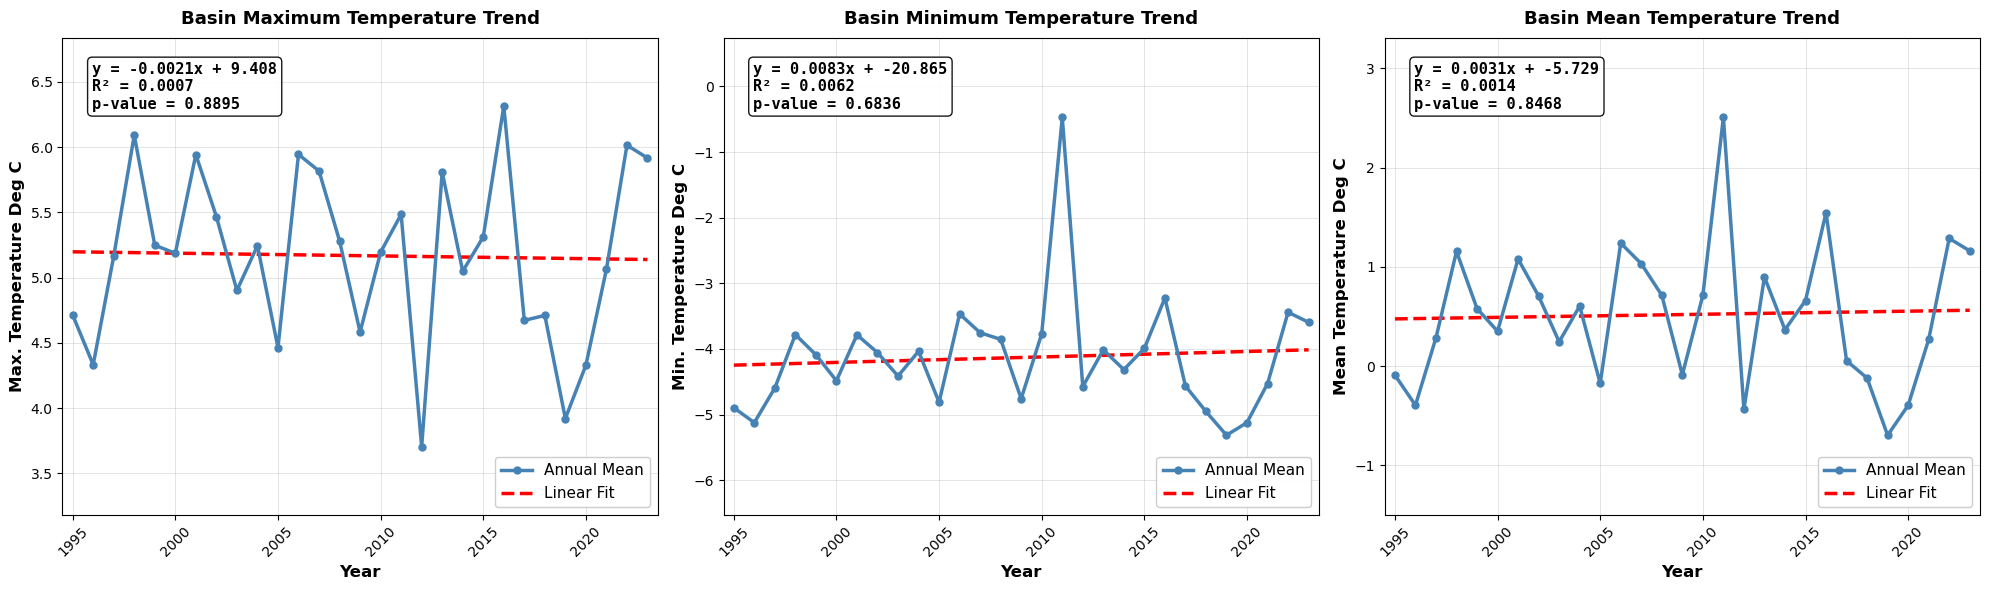


TEMPERATURE TREND STATISTICS (1995-2023)

Basin Tmax:
  Equation:          y = -0.002110x + 9.408
  R² (goodness):     0.0007
  Slope (°C/year):   -0.0021
  Total Change:      -0.06°C (over 28 years)
  p-value:           0.889495
  Significant:       No ✗

Basin Tmin:
  Equation:          y = 0.008330x + -20.865
  R² (goodness):     0.0062
  Slope (°C/year):   +0.0083
  Total Change:      +0.23°C (over 28 years)
  p-value:           0.683606
  Significant:       No ✗

Basin Tmean:
  Equation:          y = 0.003110x + -5.729
  R² (goodness):     0.0014
  Slope (°C/year):   +0.0031
  Total Change:      +0.09°C (over 28 years)
  p-value:           0.846772
  Significant:       No ✗

✓ Statistics saved to: D:\GDM Model\Thesis\Results\Mann Kendall Trend\Temperature_Trend_Statistics.xlsx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# ════════════════════════════════════════════
# LOAD DATA
# ════════════════════════════════════════════

print("="*80)
print("CREATING TEMPERATURE TREND GRAPHS (Tmax, Tmin, Tmean)")
print("="*80 + "\n")

# Load Excel file
excel_file = r"D:\GDM Model\Thesis\Results\Mann Kendall Trend\Temperature.xlsx"

try:
    df = pd.read_excel(excel_file)
except Exception as e:
    print(f"Error reading file: {e}")
    exit()

# Convert all column names to strings
df.columns = df.columns.astype(str).str.strip()

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')
df = df.dropna(subset=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"Data loaded: {len(df)} records")
print(f"Period: {df['Date'].min().date()} to {df['Date'].max().date()}\n")

# ════════════════════════════════════════════
# CALCULATE BASIN-WIDE MEANS
# ════════════════════════════════════════════

tmax_gilgit = 'Tmax (Gilgit)'
tmin_gilgit = 'Tmin (Gilgit)'
tmax_khujreeb = 'Tmax (Khujreeb)'
tmin_khunjreeb = 'Tmin (Khunjreeb)'

# Calculate basin-wide means
df['Basin_Tmax'] = (df[tmax_gilgit] + df[tmax_khujreeb]) / 2
df['Basin_Tmin'] = (df[tmin_gilgit] + df[tmin_khunjreeb]) / 2
df['Basin_Tmean'] = (df['Basin_Tmax'] + df['Basin_Tmin']) / 2

df['Year'] = df['Date'].dt.year

# Calculate annual means
annual_tmax = df.groupby('Year')['Basin_Tmax'].mean()
annual_tmin = df.groupby('Year')['Basin_Tmin'].mean()
annual_tmean = df.groupby('Year')['Basin_Tmean'].mean()

print("Basin-wide parameters calculated")
print(f"  Annual Tmax range: {annual_tmax.min():.2f} - {annual_tmax.max():.2f}°C")
print(f"  Annual Tmin range: {annual_tmin.min():.2f} - {annual_tmin.max():.2f}°C")
print(f"  Annual Tmean range: {annual_tmean.min():.2f} - {annual_tmean.max():.2f}°C\n")

# ════════════════════════════════════════════
# CREATE TREND GRAPH (1x3 LAYOUT)
# ════════════════════════════════════════════

fig = plt.figure(figsize=(20, 6))
fig.patch.set_facecolor('white')

years = annual_tmax.index.values

# ─────────────────────────────────────────────
# Plot 1: Basin Tmax
# ─────────────────────────────────────────────
ax1 = plt.subplot(1, 3, 1)
values = annual_tmax.values

# Plot line
ax1.plot(years, values, linewidth=2.5, color='steelblue', marker='o', markersize=5, label='Annual Mean', zorder=3)

# Calculate linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(years, values)
r_squared = r_value ** 2

# Plot trend line
trend_line = slope * years + intercept
ax1.plot(years, trend_line, '--', linewidth=2.5, color='red', label='Linear Fit', zorder=2)

# Add equation, R², and p-value
equation_text = f'y = {slope:.4f}x + {intercept:.3f}\nR² = {r_squared:.4f}\np-value = {p_value:.4f}'
ax1.text(0.05, 0.95, equation_text, transform=ax1.transAxes, 
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
         fontweight='bold', family='monospace')

ax1.set_xlabel('Year', fontweight='bold', fontsize=12)
ax1.set_ylabel('Max. Temperature Deg C', fontweight='bold', fontsize=12)
ax1.set_title('Basin Maximum Temperature Trend', fontweight='bold', fontsize=13, pad=10)
ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, color='gray')
ax1.legend(loc='lower right', fontsize=11, framealpha=0.95)
ax1.set_xlim(years.min()-0.5, years.max()+0.5)

# Set y-axis limits with padding
y_min_1 = values.min()
y_max_1 = values.max()
y_padding_1 = (y_max_1 - y_min_1) * 0.20  # 15% padding
ax1.set_ylim(y_min_1 - y_padding_1, y_max_1 + y_padding_1)

# Format x-axis
ax1.set_xticks(range(int(years.min()), int(years.max())+1, 5))
ax1.set_xticklabels([str(y) for y in range(int(years.min()), int(years.max())+1, 5)], fontsize=10, rotation=45)

# ─────────────────────────────────────────────
# Plot 2: Basin Tmin
# ─────────────────────────────────────────────
ax2 = plt.subplot(1, 3, 2)
values = annual_tmin.values

# Plot line
ax2.plot(years, values, linewidth=2.5, color='steelblue', marker='o', markersize=5, label='Annual Mean', zorder=3)

# Calculate linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(years, values)
r_squared = r_value ** 2

# Plot trend line
trend_line = slope * years + intercept
ax2.plot(years, trend_line, '--', linewidth=2.5, color='red', label='Linear Fit', zorder=2)

# Add equation, R², and p-value
equation_text = f'y = {slope:.4f}x + {intercept:.3f}\nR² = {r_squared:.4f}\np-value = {p_value:.4f}'
ax2.text(0.05, 0.95, equation_text, transform=ax2.transAxes, 
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
         fontweight='bold', family='monospace')

ax2.set_xlabel('Year', fontweight='bold', fontsize=12)
ax2.set_ylabel('Min. Temperature Deg C', fontweight='bold', fontsize=12)
ax2.set_title('Basin Minimum Temperature Trend', fontweight='bold', fontsize=13, pad=10)
ax2.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, color='gray')
ax2.legend(loc='lower right', fontsize=11, framealpha=0.95)
ax2.set_xlim(years.min()-0.5, years.max()+0.5)

# Set y-axis limits with padding
y_min_2 = values.min()
y_max_2 = values.max()
y_padding_2 = (y_max_2 - y_min_2) * 0.25  # 15% padding
ax2.set_ylim(y_min_2 - y_padding_2, y_max_2 + y_padding_2)

# Format x-axis
ax2.set_xticks(range(int(years.min()), int(years.max())+1, 5))
ax2.set_xticklabels([str(y) for y in range(int(years.min()), int(years.max())+1, 5)], fontsize=10, rotation=45)

# ─────────────────────────────────────────────
# Plot 3: Basin Tmean
# ─────────────────────────────────────────────
ax3 = plt.subplot(1, 3, 3)
values = annual_tmean.values

# Plot line
ax3.plot(years, values, linewidth=2.5, color='steelblue', marker='o', markersize=5, label='Annual Mean', zorder=3)

# Calculate linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(years, values)
r_squared = r_value ** 2

# Plot trend line
trend_line = slope * years + intercept
ax3.plot(years, trend_line, '--', linewidth=2.5, color='red', label='Linear Fit', zorder=2)

# Add equation, R², and p-value
equation_text = f'y = {slope:.4f}x + {intercept:.3f}\nR² = {r_squared:.4f}\np-value = {p_value:.4f}'
ax3.text(0.05, 0.95, equation_text, transform=ax3.transAxes, 
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
         fontweight='bold', family='monospace')

ax3.set_xlabel('Year', fontweight='bold', fontsize=14)
ax3.set_ylabel('Mean Temperature Deg C', fontweight='bold', fontsize=14)
ax3.set_title('Basin Mean Temperature Trend', fontweight='bold', fontsize=13, pad=10)
ax3.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, color='gray')
ax3.legend(loc='lower right', fontsize=11, framealpha=0.95)
ax3.set_xlim(years.min()-0.5, years.max()+0.5)

# Set y-axis limits with padding
y_min_3 = values.min()
y_max_3 = values.max()
y_padding_3 = (y_max_3 - y_min_3) * 0.25 # 15% padding
ax3.set_ylim(y_min_3 - y_padding_3, y_max_3 + y_padding_3)

# Format x-axis
ax3.set_xticks(range(int(years.min()), int(years.max())+1, 5))
ax3.set_xticklabels([str(y) for y in range(int(years.min()), int(years.max())+1, 5)], fontsize=14, rotation=45)

plt.tight_layout()
plot_path = r'D:\GDM Model\Thesis\Results\Mann Kendall Trend\Temperature_Trend_Graphs.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Trend graphs saved to: {plot_path}")
plt.show()

# ════════════════════════════════════════════
# PRINT TREND STATISTICS
# ════════════════════════════════════════════

print("\n" + "="*80)
print("TEMPERATURE TREND STATISTICS (1995-2023)")
print("="*80 + "\n")

results = []

for name, data in [('Basin Tmax', annual_tmax), ('Basin Tmin', annual_tmin), ('Basin Tmean', annual_tmean)]:
    slope, intercept, r_value, p_value, std_err = stats.linregress(years, data.values)
    r_squared = r_value ** 2
    annual_change = slope
    total_change = slope * (years[-1] - years[0])
    
    print(f"{name}:")
    print(f"  Equation:          y = {slope:.6f}x + {intercept:.3f}")
    print(f"  R² (goodness):     {r_squared:.4f}")
    print(f"  Slope (°C/year):   {annual_change:+.4f}")
    print(f"  Total Change:      {total_change:+.2f}°C (over {years[-1] - years[0]} years)")
    print(f"  p-value:           {p_value:.6f}")
    print(f"  Significant:       {'Yes ✓' if p_value < 0.05 else 'No ✗'}\n")
    
    results.append({
        'Parameter': name,
        'Equation': f'y = {slope:.6f}x + {intercept:.3f}',
        'R²': f'{r_squared:.4f}',
        'Slope (°C/year)': f'{annual_change:+.4f}',
        'Total Change (°C)': f'{total_change:+.2f}',
        'p-value': f'{p_value:.6f}',
        'Significant': 'Yes ✓' if p_value < 0.05 else 'No ✗'
    })

# Save results to Excel
results_df = pd.DataFrame(results)
results_path = r'D:\GDM Model\Thesis\Results\Mann Kendall Trend\Temperature_Trend_Statistics.xlsx'
results_df.to_excel(results_path, index=False)
print(f"✓ Statistics saved to: {results_path}")

print("="*80)

COMBINED TEMPERATURE ANALYSIS: LINEAR TREND + CUBIC REGRESSION

Data loaded: 10592 records
Period: 1995-01-01 to 2023-12-31

Basin-wide parameters calculated
  Annual Tmax range: 3.71 - 6.32°C
  Annual Tmin range: -5.31 - -0.47°C
  Annual Tmean range: -0.70 - 2.51°C

✓ Combined trend graphs saved to: D:\GDM Model\Thesis\Results\Mann Kendall Trend\Combined_Trend_Analysis.png


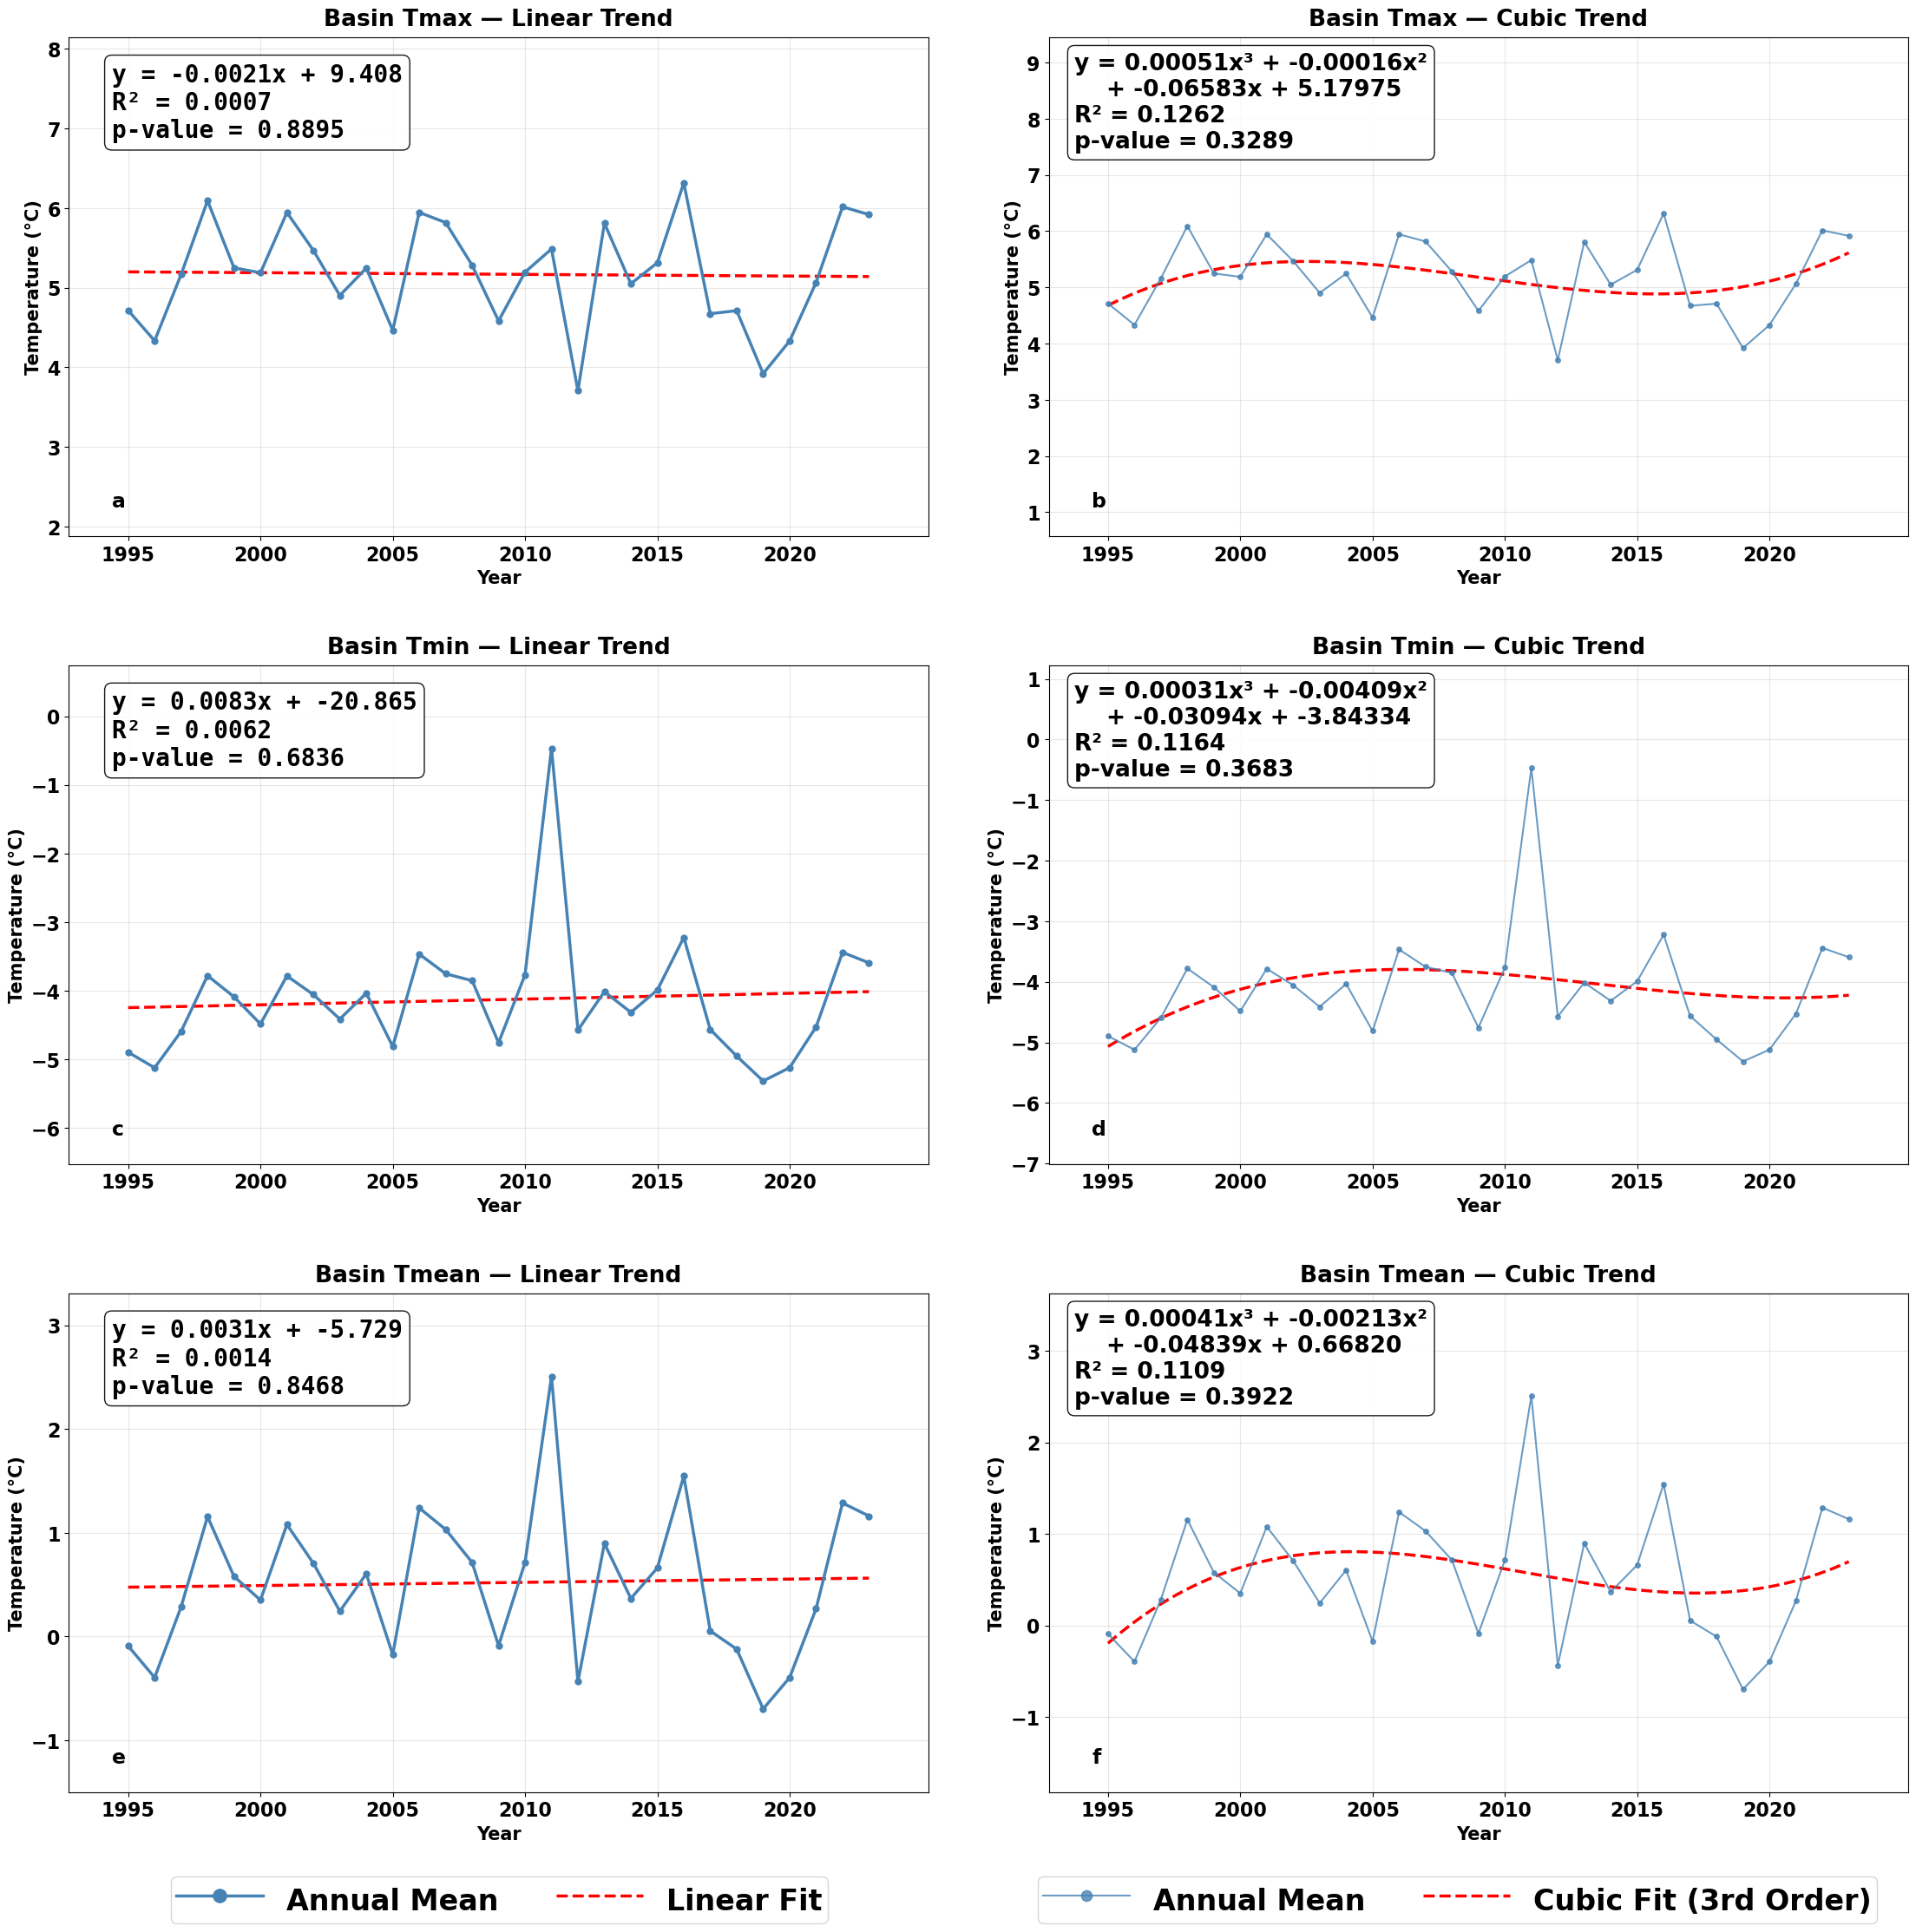


LINEAR REGRESSION STATISTICS (1995-2023)

Basin Tmax:
  Equation:          y = -0.002110x + 9.408
  R² (goodness):     0.0007
  Slope (°C/year):   -0.0021
  Total Change:      -0.06°C (over 28 years)
  p-value:           0.889495
  Significant:       No ✗

Basin Tmin:
  Equation:          y = 0.008330x + -20.865
  R² (goodness):     0.0062
  Slope (°C/year):   +0.0083
  Total Change:      +0.23°C (over 28 years)
  p-value:           0.683606
  Significant:       No ✗

Basin Tmean:
  Equation:          y = 0.003110x + -5.729
  R² (goodness):     0.0014
  Slope (°C/year):   +0.0031
  Total Change:      +0.09°C (over 28 years)
  p-value:           0.846772
  Significant:       No ✗


CUBIC REGRESSION STATISTICS (1995-2023)

Basin Tmax:
  R²:              0.1262
  p-value:         0.3289
  Turning Points:  [np.float64(2015.7), np.float64(2002.5)]
  Total Change:    +0.9366°C

Basin Tmin:
  R²:              0.1164
  p-value:         0.3683
  Turning Points:  [np.float64(2020.6), np.float64

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# ════════════════════════════════════════════
# LOAD DATA
# ════════════════════════════════════════════

print("="*80)
print("COMBINED TEMPERATURE ANALYSIS: LINEAR TREND + CUBIC REGRESSION")
print("="*80 + "\n")

excel_file = r"D:\GDM Model\Thesis\Results\Mann Kendall Trend\Temperature.xlsx"

try:
    df = pd.read_excel(excel_file)
except Exception as e:
    print(f"Error reading file: {e}")
    exit()

# Convert all column names to strings
df.columns = df.columns.astype(str).str.strip()

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')
df = df.dropna(subset=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"Data loaded: {len(df)} records")
print(f"Period: {df['Date'].min().date()} to {df['Date'].max().date()}\n")

# ════════════════════════════════════════════
# CALCULATE BASIN-WIDE MEANS
# ════════════════════════════════════════════

tmax_gilgit = 'Tmax (Gilgit)'
tmin_gilgit = 'Tmin (Gilgit)'
tmax_khujreeb = 'Tmax (Khujreeb)'
tmin_khunjreeb = 'Tmin (Khunjreeb)'

df['Basin_Tmax'] = (df[tmax_gilgit] + df[tmax_khujreeb]) / 2
df['Basin_Tmin'] = (df[tmin_gilgit] + df[tmin_khunjreeb]) / 2
df['Basin_Tmean'] = (df['Basin_Tmax'] + df['Basin_Tmin']) / 2

df['Year'] = df['Date'].dt.year

# Calculate annual means
annual = df.groupby('Year')[['Basin_Tmax', 'Basin_Tmin', 'Basin_Tmean']].mean().reset_index()

years = annual['Year'].values
annual_tmax = annual['Basin_Tmax'].values
annual_tmin = annual['Basin_Tmin'].values
annual_tmean = annual['Basin_Tmean'].values

print("Basin-wide parameters calculated")
print(f"  Annual Tmax range: {annual_tmax.min():.2f} - {annual_tmax.max():.2f}°C")
print(f"  Annual Tmin range: {annual_tmin.min():.2f} - {annual_tmin.max():.2f}°C")
print(f"  Annual Tmean range: {annual_tmean.min():.2f} - {annual_tmean.max():.2f}°C\n")

# ════════════════════════════════════════════
# CREATE COMBINED FIGURE (3 ROWS x 2 COLUMNS)
# ════════════════════════════════════════════

fig = plt.figure(figsize=(23, 24))
fig.patch.set_facecolor('white')

parameters = ['Basin Tmax', 'Basin Tmin', 'Basin Tmean']
data_list = [annual_tmax, annual_tmin, annual_tmean]
labels = ['a', 'b', 'c', 'd', 'e', 'f']

# ════════════════════════════════════════════
# FUNCTION: LINEAR REGRESSION (Mann Kendall Style)
# ════════════════════════════════════════════

def plot_linear_trend(ax, years, values, param_name, label, row_idx):
    """Plot linear trend analysis"""
    # Use steelblue for all annual means
    ax.plot(years, values, linewidth=2.5, color='steelblue', marker='o', markersize=5, 
            label='Annual Mean', zorder=3)

    # Calculate linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(years, values)
    r_squared = r_value ** 2

    # Plot trend line
    trend_line = slope * years + intercept
    ax.plot(years, trend_line, '--', linewidth=2.5, color='red', label='Linear Fit', zorder=2)

    # Add equation, R², and p-value — bold + black
    equation_text = (f'y = {slope:.4f}x + {intercept:.3f}\n'
                     f'R² = {r_squared:.4f}\n'
                     f'p-value = {p_value:.4f}')
    ax.text(0.05, 0.95, equation_text, transform=ax.transAxes, 
            fontsize=20, fontweight='bold', color='black',
            verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
            family='monospace')

    ax.set_xlabel('Year', fontweight='bold', fontsize=15, color='black')
    ax.set_ylabel('Temperature (°C)', fontweight='bold', fontsize=15, color='black')
    ax.set_title(f'{param_name} — Linear Trend', fontweight='bold', fontsize=19, pad=10)
    ax.grid(True, alpha=0.3)
    # Per-subplot legend removed — single shared legend added at figure level

    # Increased X-axis padding
    x_padding = (years.max() - years.min()) * 0.08
    ax.set_xlim(years.min() - x_padding, years.max() + x_padding)

    # Increased Y-axis padding - LARGER for top row (a, b)
    y_min = values.min()
    y_max = values.max()
    if row_idx == 0:  # First row (Tmax) - INCREASE padding significantly
        y_padding = (y_max - y_min) * 0.70
    else:
        y_padding = (y_max - y_min) * 0.25
    ax.set_ylim(y_min - y_padding, y_max + y_padding)

    # Format x-axis - BOLD years
    ax.set_xticks(range(int(years.min()), int(years.max())+1, 5))
    ax.tick_params(axis='x', rotation=0, labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    
    # Make x-axis tick labels bold + black + larger
    for label_x in ax.get_xticklabels():
        label_x.set_fontweight('bold')
        label_x.set_fontsize(16)
        label_x.set_color('black')

    # Make y-axis tick labels bold + black + larger
    for label_y in ax.get_yticklabels():
        label_y.set_fontweight('bold')
        label_y.set_fontsize(16)
        label_y.set_color('black')

    # Add label at BOTTOM-LEFT corner
    ax.text(0.05, 0.05, label, transform=ax.transAxes, 
            fontsize=17, fontweight='bold', verticalalignment='bottom',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.0, edgecolor='none'))

# ════════════════════════════════════════════
# FUNCTION: CUBIC REGRESSION
# ════════════════════════════════════════════

def plot_cubic_trend(ax, years, values, param_name, label, row_idx):
    """Plot cubic polynomial trend analysis"""
    x = years.copy()
    y = values.copy()

    # Normalize x for numerical stability
    x_norm = x - x.mean()

    # Fit 3rd order polynomial
    coeffs = np.polyfit(x_norm, y, 3)
    poly = np.poly1d(coeffs)

    # Generate smooth curve for plotting
    x_smooth = np.linspace(x_norm.min(), x_norm.max(), 300)
    y_smooth = poly(x_smooth)
    x_smooth_orig = x_smooth + x.mean()

    # Calculate R²
    y_pred = poly(x_norm)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    # Calculate Adjusted R²
    n = len(y)
    p = 3
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    # Calculate p-value using F-test
    ms_res = ss_res / (n - p - 1)
    ms_reg = (ss_tot - ss_res) / p
    f_stat = ms_reg / ms_res
    p_value = 1 - stats.f.cdf(f_stat, p, n - p - 1)

    # Find turning points
    a, b, c, d = coeffs
    derivative = np.polyder(poly)
    turning_roots = np.roots(derivative)

    turning_points = []
    for root in turning_roots:
        if np.isreal(root):
            real_root = np.real(root) + x.mean()
            if x.min() <= real_root <= x.max():
                turning_points.append(round(real_root, 1))

    # Calculate trend direction
    trend_start = poly(x_norm[0])
    trend_end = poly(x_norm[-1])
    total_change = trend_end - trend_start

    # Plot - Use steelblue for annual means
    ax.plot(x, y, 'o-', color='steelblue', linewidth=1.5, markersize=4, 
            label='Annual Mean', alpha=0.8, zorder=3)
    ax.plot(x_smooth_orig, y_smooth, '--', color='red', linewidth=2.5, 
            label='Cubic Fit (3rd Order)', zorder=2)

    # Equation and stats box — bold + black
    eq_text = (f'y = {a:.5f}x³ + {b:.5f}x²\n'
               f'    + {c:.5f}x + {d:.5f}\n'
               f'R² = {r2:.4f}\n'
               f'p-value = {p_value:.4f}')
    ax.text(0.03, 0.97, eq_text, transform=ax.transAxes, fontsize=19,
            fontweight='bold', color='black',
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

    ax.set_title(f'{param_name} — Cubic Trend', fontweight='bold', fontsize=19, pad=10)
    ax.set_xlabel('Year', fontweight='bold', fontsize=15, color='black')
    ax.set_ylabel('Temperature (°C)', fontweight='bold', fontsize=15, color='black')
    # Per-subplot legend removed — single shared legend added at figure level
    ax.grid(True, alpha=0.3)

    # Increased X-axis padding
    x_padding = (x.max() - x.min()) * 0.08
    ax.set_xlim(x.min() - x_padding, x.max() + x_padding)

    # Increased Y-axis padding - LARGER for top row (a, b)
    y_min = y.min()
    y_max = y.max()
    if row_idx == 0:  # First row (Tmax) - INCREASE padding significantly
        y_padding = (y_max - y_min) * 1.20
    else:
        y_padding = (y_max - y_min) * 0.35
    ax.set_ylim(y_min - y_padding, y_max + y_padding)

    # Format x-axis - BOLD years
    ax.set_xticks(range(int(x.min()), int(x.max())+1, 5))
    ax.tick_params(axis='x', rotation=0, labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    
    # Make x-axis tick labels bold + black + larger
    for label_x in ax.get_xticklabels():
        label_x.set_fontweight('bold')
        label_x.set_fontsize(16)
        label_x.set_color('black')

    # Make y-axis tick labels bold + black + larger
    for label_y in ax.get_yticklabels():
        label_y.set_fontweight('bold')
        label_y.set_fontsize(16)
        label_y.set_color('black')

    # Add label at BOTTOM-LEFT corner
    ax.text(0.05, 0.05, label, transform=ax.transAxes, 
            fontsize=17, fontweight='bold', verticalalignment='bottom',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.0, edgecolor='none'))

    return {
        'R2': round(r2, 4),
        'p_value': round(p_value, 4),
        'Turning_Points': str(turning_points),
        'Total_Change': round(total_change, 4)
    }

# ════════════════════════════════════════════
# CREATE 3x2 SUBPLOTS
# ════════════════════════════════════════════

all_cubic_results = {}
label_idx = 0
ax_left_ref = None    # will hold one linear-trend axis, for the shared legend
ax_right_ref = None   # will hold one cubic-trend axis, for the shared legend

for row, (param, data) in enumerate(zip(parameters, data_list)):
    # LEFT COLUMN: Linear Trend (Mann Kendall style) - gets labels a, c, e
    ax_left = plt.subplot(3, 2, 2*row + 1)
    plot_linear_trend(ax_left, years, data, param, labels[label_idx], row)
    label_idx += 1
    if ax_left_ref is None:
        ax_left_ref = ax_left

    # RIGHT COLUMN: Cubic Regression - gets labels b, d, f
    ax_right = plt.subplot(3, 2, 2*row + 2)
    cubic_res = plot_cubic_trend(ax_right, years, data, param, labels[label_idx], row)
    all_cubic_results[param] = cubic_res
    label_idx += 1
    if ax_right_ref is None:
        ax_right_ref = ax_right

plt.tight_layout(pad=4.0, h_pad=5.0, w_pad=5.0)

# ════════════════════════════════════════════
# SINGLE SHARED LEGEND FOR EACH COLUMN
# ════════════════════════════════════════════

handles_l, labels_l = ax_left_ref.get_legend_handles_labels()
handles_r, labels_r = ax_right_ref.get_legend_handles_labels()

fig.legend(handles_l, labels_l, loc='lower center', bbox_to_anchor=(0.27, 0.05),
           ncol=2, fontsize=15, prop={'weight': 'bold', 'size': 24}, frameon=True,
           markerscale=2.2, handlelength=3, handleheight=1.5,
           labelspacing=1.0, borderpad=0.2)
fig.legend(handles_r, labels_r, loc='lower center', bbox_to_anchor=(0.75, 0.05),
           ncol=2, fontsize=15, prop={'weight': 'bold', 'size': 24}, frameon=True,
           markerscale=2.2, handlelength=3, handleheight=1.5,
           labelspacing=1.0, borderpad=0.2)

plt.subplots_adjust(bottom=0.12)
# Save combined figure
combined_plot_path = r'D:\GDM Model\Thesis\Results\Mann Kendall Trend\Combined_Trend_Analysis.png'
plt.savefig(combined_plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Combined trend graphs saved to: {combined_plot_path}")
plt.show()

# ════════════════════════════════════════════
# PRINT STATISTICS
# ════════════════════════════════════════════

print("\n" + "="*80)
print("LINEAR REGRESSION STATISTICS (1995-2023)")
print("="*80 + "\n")

linear_results = []

for param, data in zip(parameters, data_list):
    slope, intercept, r_value, p_value, std_err = stats.linregress(years, data)
    r_squared = r_value ** 2
    annual_change = slope
    total_change = slope * (years[-1] - years[0])

    print(f"{param}:")
    print(f"  Equation:          y = {slope:.6f}x + {intercept:.3f}")
    print(f"  R² (goodness):     {r_squared:.4f}")
    print(f"  Slope (°C/year):   {annual_change:+.4f}")
    print(f"  Total Change:      {total_change:+.2f}°C (over {years[-1] - years[0]} years)")
    print(f"  p-value:           {p_value:.6f}")
    print(f"  Significant:       {'Yes ✓' if p_value < 0.05 else 'No ✗'}\n")

    linear_results.append({
        'Parameter': param,
        'Equation': f'y = {slope:.6f}x + {intercept:.3f}',
        'R²': f'{r_squared:.4f}',
        'Slope (°C/year)': f'{annual_change:+.4f}',
        'Total Change (°C)': f'{total_change:+.2f}',
        'p-value': f'{p_value:.6f}',
        'Significant': 'Yes ✓' if p_value < 0.05 else 'No ✗'
    })

print("\n" + "="*80)
print("CUBIC REGRESSION STATISTICS (1995-2023)")
print("="*80 + "\n")

for param, res in all_cubic_results.items():
    print(f"{param}:")
    print(f"  R²:              {res['R2']:.4f}")
    print(f"  p-value:         {res['p_value']:.4f}")
    print(f"  Turning Points:  {res['Turning_Points']}")
    print(f"  Total Change:    {res['Total_Change']:+.4f}°C\n")

# Save results to Excel
results_df = pd.DataFrame(linear_results)
results_path = r'D:\GDM Model\Thesis\Results\Mann Kendall Trend\Combined_Analysis_Results.xlsx'
results_df.to_excel(results_path, index=False)
print(f"✓ Combined statistics saved to: {results_path}")

print("="*80)

## <center> Precipitation

PRECIPITATION MANN-KENDALL TREND ANALYSIS (1995-2023)

Data loaded: 10592 records
Period: 1995-01-01 to 2023-12-31

Annual Precipitation Summary:
  Period: 1995 to 2023
  Annual Precip range: 489.00 - 831.55 mm
  Mean Annual Precip: 652.54 mm
  Std Dev: 87.02 mm

MANN-KENDALL TREND TEST RESULTS

Mann-Kendall Test Results:
  Theil-Sen Slope:     +0.8976 mm/year
  Total Change:        +25.13 mm (over 28 years)
  S Statistic:         16
  Z Statistic:         +0.2814
  p-value:             0.778426
  Trend:               No Significant Trend
  Significant (α=0.05): No ✗

Linear Regression (for comparison):
  Equation:            y = 0.406752x + -164.626
  R²:                  0.0015
  Slope:               +0.4068 mm/year
  Total Change:        +11.39 mm
  p-value:             0.840370

✓ Precipitation trend graph saved to: D:\GDM Model\Thesis\Results\Mann Kendall Trend\Precipitation_Mann_Kendall_Trend.png


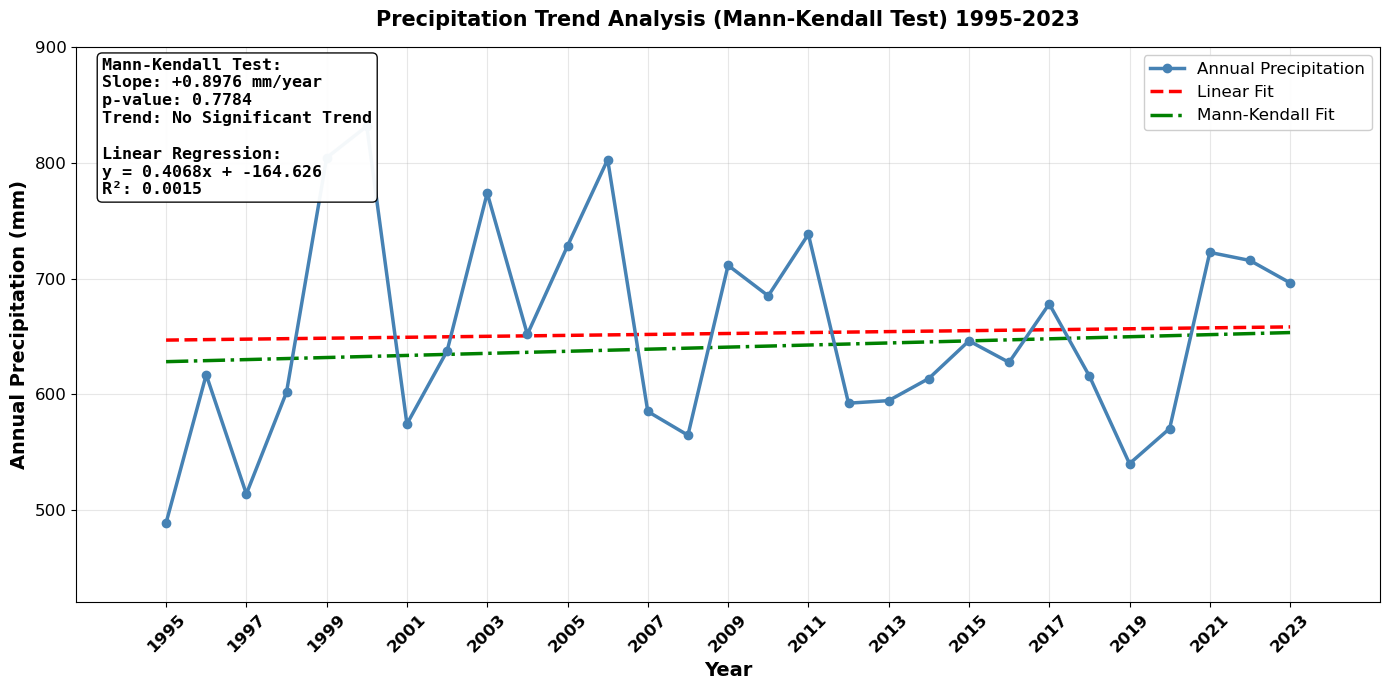

✓ Results saved to Excel: D:\GDM Model\Thesis\Results\Mann Kendall Trend\Precipitation_Mann_Kendall_Results.xlsx

SUMMARY

Precipitation from 1995-2023:
  • Mann-Kendall test shows no significant trend
  • Average change: +0.8976 mm/year (Theil-Sen slope)
  • Total change over 28 years: +25.13 mm
  • Statistical significance: p > 0.05 (Not Significant)
  • Linear R²: 0.0015 (explains 0.15% of variance)



In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# ════════════════════════════════════════════
# LOAD DATA
# ════════════════════════════════════════════

print("="*80)
print("PRECIPITATION MANN-KENDALL TREND ANALYSIS (1995-2023)")
print("="*80 + "\n")

excel_file = r"D:\GDM Model\Thesis\Results\precipitation\Historical.xlsx"

try:
    df = pd.read_excel(excel_file)
except Exception as e:
    print(f"Error reading file: {e}")
    exit()

# Convert all column names to strings
df.columns = df.columns.astype(str).str.strip()

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')
df = df.dropna(subset=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"Data loaded: {len(df)} records")
print(f"Period: {df['Date'].min().date()} to {df['Date'].max().date()}\n")

# ════════════════════════════════════════════
# EXTRACT YEAR AND CALCULATE ANNUAL PRECIPITATION
# ════════════════════════════════════════════

df['Year'] = df['Date'].dt.year

# Calculate annual total precipitation
annual_precip = df.groupby('Year')['Precp'].sum().reset_index()
annual_precip.columns = ['Year', 'Annual_Precipitation']

years = annual_precip['Year'].values
precip = annual_precip['Annual_Precipitation'].values

print("Annual Precipitation Summary:")
print(f"  Period: {years.min()} to {years.max()}")
print(f"  Annual Precip range: {precip.min():.2f} - {precip.max():.2f} mm")
print(f"  Mean Annual Precip: {precip.mean():.2f} mm")
print(f"  Std Dev: {precip.std():.2f} mm\n")

# ════════════════════════════════════════════
# MANN-KENDALL TEST FUNCTION
# ════════════════════════════════════════════

def mann_kendall_test(data):
    """
    Performs Mann-Kendall trend test
    
    Returns:
    - slope: Theil-Sen slope
    - p_value: p-value of the test
    - trend: 'increasing', 'decreasing', or 'no trend'
    """
    n = len(data)
    
    # Calculate S statistic
    s = 0
    for i in range(n-1):
        for j in range(i+1, n):
            s += np.sign(data[j] - data[i])
    
    # Calculate variance
    g = 0
    for i in range(n):
        for j in range(i+1, n):
            if data[i] == data[j]:
                g += 1
    
    var_s = (n*(n-1)*(2*n+5) - g) / 18
    
    # Calculate Z statistic
    if s > 0:
        z = (s - 1) / np.sqrt(var_s)
    elif s < 0:
        z = (s + 1) / np.sqrt(var_s)
    else:
        z = 0
    
    # Calculate p-value (two-tailed)
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    
    # Theil-Sen slope
    slopes = []
    for i in range(n-1):
        for j in range(i+1, n):
            if years[j] != years[i]:
                slopes.append((data[j] - data[i]) / (years[j] - years[i]))
    slope = np.median(slopes) if slopes else 0
    
    # Determine trend
    if p_value < 0.05:
        trend = 'Increasing' if s > 0 else 'Decreasing'
    else:
        trend = 'No Significant Trend'
    
    return slope, p_value, z, s, var_s, trend

# Perform Mann-Kendall test
slope, p_value, z_stat, s_stat, var_s, trend = mann_kendall_test(precip)

# Calculate linear regression for comparison
slope_lr, intercept_lr, r_value_lr, p_value_lr, std_err_lr = stats.linregress(years, precip)
r_squared_lr = r_value_lr ** 2

# Calculate total change
total_change = slope * (years[-1] - years[0])

# ════════════════════════════════════════════
# PRINT MANN-KENDALL TEST RESULTS
# ════════════════════════════════════════════

print("="*80)
print("MANN-KENDALL TREND TEST RESULTS")
print("="*80 + "\n")

print(f"Mann-Kendall Test Results:")
print(f"  Theil-Sen Slope:     {slope:+.4f} mm/year")
print(f"  Total Change:        {total_change:+.2f} mm (over {years[-1] - years[0]} years)")
print(f"  S Statistic:         {s_stat:.0f}")
print(f"  Z Statistic:         {z_stat:+.4f}")
print(f"  p-value:             {p_value:.6f}")
print(f"  Trend:               {trend}")
print(f"  Significant (α=0.05): {'Yes ✓' if p_value < 0.05 else 'No ✗'}\n")

print(f"Linear Regression (for comparison):")
print(f"  Equation:            y = {slope_lr:.6f}x + {intercept_lr:.3f}")
print(f"  R²:                  {r_squared_lr:.4f}")
print(f"  Slope:               {slope_lr:+.4f} mm/year")
print(f"  Total Change:        {slope_lr * (years[-1] - years[0]):+.2f} mm")
print(f"  p-value:             {p_value_lr:.6f}\n")

# ════════════════════════════════════════════
# CREATE VISUALIZATION
# ════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('white')

# Plot annual precipitation
ax.plot(years, precip, linewidth=2.5, color='steelblue', marker='o', markersize=6, 
        label='Annual Precipitation', zorder=3)

# Plot linear regression line
trend_line = slope_lr * years + intercept_lr
ax.plot(years, trend_line, '--', linewidth=2.5, color='red', label='Linear Fit', zorder=2)

# Add Mann-Kendall trend line (Theil-Sen slope)
# Calculate intercept for Mann-Kendall line (using median of intercepts)
intercepts_mk = [precip[i] - slope * years[i] for i in range(len(precip))]
intercept_mk = np.median(intercepts_mk)
trend_line_mk = slope * years + intercept_mk
ax.plot(years, trend_line_mk, '-.', linewidth=2.5, color='green', label='Mann-Kendall Fit', zorder=2)

# Add statistics box
equation_text = (f'Mann-Kendall Test:\n'
                 f'Slope: {slope:+.4f} mm/year\n'
                 f'p-value: {p_value:.4f}\n'
                 f'Trend: {trend}\n\n'
                 f'Linear Regression:\n'
                 f'y = {slope_lr:.4f}x + {intercept_lr:.3f}\n'
                 f'R²: {r_squared_lr:.4f}')
ax.text(0.02, 0.98, equation_text, transform=ax.transAxes, 
        fontsize=12, verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.95),
        fontweight='bold', family='monospace')

ax.set_xlabel('Year', fontweight='bold', fontsize=14)
ax.set_ylabel('Annual Precipitation (mm)', fontweight='bold', fontsize=14)
ax.set_title('Precipitation Trend Analysis (Mann-Kendall Test) 1995-2023', 
             fontweight='bold', fontsize=15, pad=15)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=12, framealpha=0.95)

# Format axes
x_padding = (years.max() - years.min()) * 0.08
ax.set_xlim(years.min() - x_padding, years.max() + x_padding)

y_min = precip.min()
y_max = precip.max()
y_padding = (y_max - y_min) * 0.2
ax.set_ylim(y_min - y_padding, y_max + y_padding)

# Bold X-axis years
ax.set_xticks(range(int(years.min()), int(years.max())+1, 2))
ax.tick_params(axis='x', rotation=45, labelsize=12)
ax.tick_params(axis='y', labelsize=12)

for label_x in ax.get_xticklabels():
    label_x.set_fontweight('bold')
    label_x.set_fontsize(12)

for label_y in ax.get_yticklabels():
    label_y.set_fontweight('normal')
    label_y.set_fontsize(12)

plt.tight_layout()

# Save figure
plot_path = r'D:\GDM Model\Thesis\Results\Mann Kendall Trend\Precipitation_Mann_Kendall_Trend.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Precipitation trend graph saved to: {plot_path}")
plt.show()

# ════════════════════════════════════════════
# SAVE RESULTS TO EXCEL
# ════════════════════════════════════════════

# Create results dataframe
results_data = {
    'Metric': [
        'Period',
        'Years',
        'Annual Precip Min (mm)',
        'Annual Precip Max (mm)',
        'Mean Annual Precip (mm)',
        'Mann-Kendall Slope (mm/year)',
        'Mann-Kendall Total Change (mm)',
        'Mann-Kendall p-value',
        'Mann-Kendall Z-statistic',
        'Mann-Kendall S-statistic',
        'Mann-Kendall Trend',
        'Significant (α=0.05)',
        'Linear Regression Slope (mm/year)',
        'Linear Regression Total Change (mm)',
        'Linear Regression R²',
        'Linear Regression p-value'
    ],
    'Value': [
        f"{years.min()}-{years.max()}",
        len(years),
        f"{precip.min():.2f}",
        f"{precip.max():.2f}",
        f"{precip.mean():.2f}",
        f"{slope:+.4f}",
        f"{total_change:+.2f}",
        f"{p_value:.6f}",
        f"{z_stat:+.4f}",
        f"{s_stat:.0f}",
        trend,
        'Yes ✓' if p_value < 0.05 else 'No ✗',
        f"{slope_lr:+.4f}",
        f"{slope_lr * (years[-1] - years[0]):+.2f}",
        f"{r_squared_lr:.4f}",
        f"{p_value_lr:.6f}"
    ]
}

results_df = pd.DataFrame(results_data)

# Save annual precipitation data with results
annual_precip_export = annual_precip.copy()
annual_precip_export['Trend_Line_MK'] = slope * annual_precip_export['Year'] + intercept_mk
annual_precip_export['Trend_Line_LR'] = slope_lr * annual_precip_export['Year'] + intercept_lr

# Save to Excel with multiple sheets
output_path = r'D:\GDM Model\Thesis\Results\Mann Kendall Trend\Precipitation_Mann_Kendall_Results.xlsx'
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    results_df.to_excel(writer, sheet_name='Test Results', index=False)
    annual_precip_export.to_excel(writer, sheet_name='Annual Data', index=False)

print(f"✓ Results saved to Excel: {output_path}")

# ════════════════════════════════════════════
# PRINT SUMMARY
# ════════════════════════════════════════════

print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"\nPrecipitation from 1995-2023:")
print(f"  • Mann-Kendall test shows {trend.lower()}")
print(f"  • Average change: {slope:+.4f} mm/year (Theil-Sen slope)")
print(f"  • Total change over 28 years: {total_change:+.2f} mm")
print(f"  • Statistical significance: {'p < 0.05 (Significant)' if p_value < 0.05 else 'p > 0.05 (Not Significant)'}")
print(f"  • Linear R²: {r_squared_lr:.4f} (explains {r_squared_lr*100:.2f}% of variance)")

print("\n" + "="*80)

PRECIPITATION ANALYSIS: MANN-KENDALL + CUBIC REGRESSION (1995-2023)

Data loaded: 10592 records
Period: 1995-01-01 to 2023-12-31

Mean Annual Precip : 652.54 mm
Std Dev            : 87.02 mm
Range              : 489.00 - 831.55 mm

MANN-KENDALL TREND TEST RESULTS
  Theil-Sen Slope  : +0.8976 mm/year
  Total Change     : +25.13 mm over 28 years
  Z Statistic      : +0.2814
  p-value          : 0.778426
  Trend            : No Significant Trend
  Significant      : No ✗

CUBIC REGRESSION RESULTS
  R²               : 0.2946
  Adjusted R²      : 0.2100
  F-statistic      : 3.4804
  p-value          : 0.030800
  Significant      : Yes ✓
  Trend            : Overall Increasing
  Total Change     : +200.70 mm
  Turning Points   : [np.float64(2003.5), np.float64(2016.4)]


✓ Plot saved to: D:\GDM Model\Thesis\Results\precipitation\Precipitation_Combined_Analysis.png


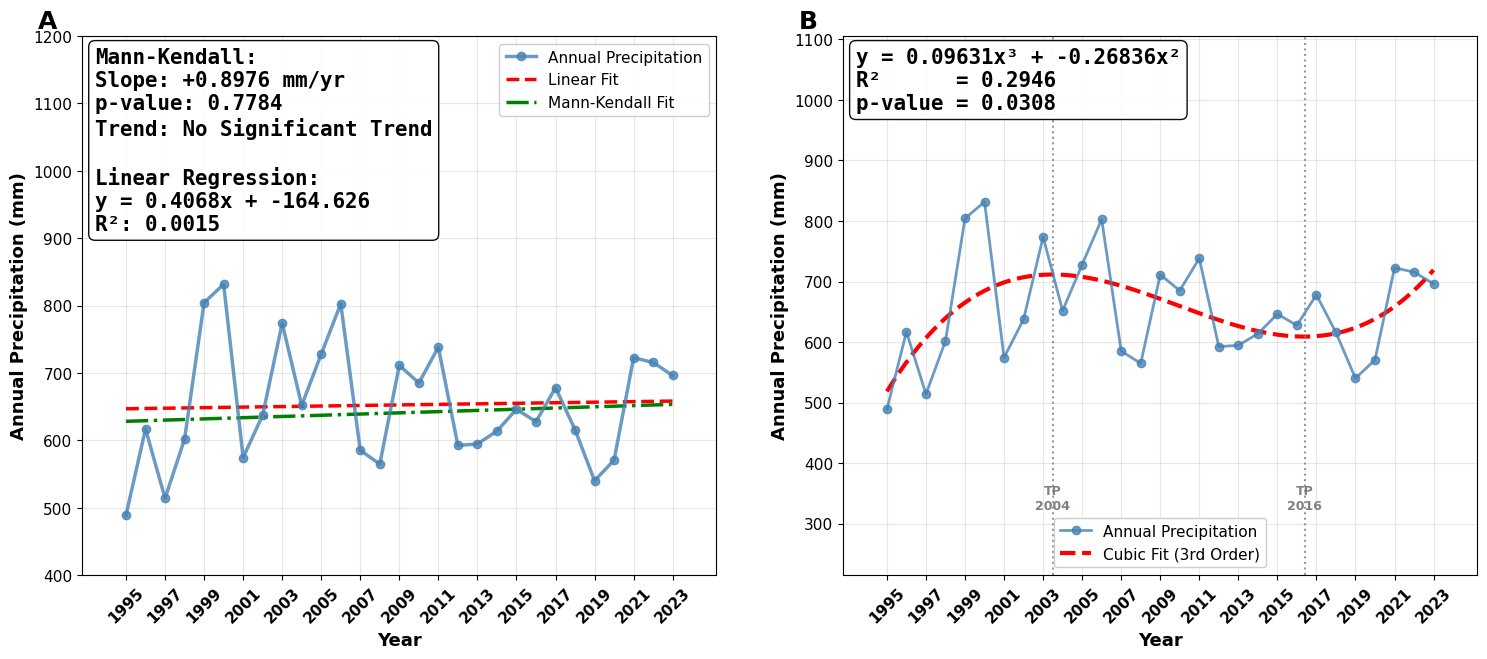

✓ Results saved to Excel: D:\GDM Model\Thesis\Results\precipitation\Precipitation_Combined_Results.xlsx

SUMMARY

  Mann-Kendall:
    Trend     : No Significant Trend
    Slope     : +0.8976 mm/year
    Change    : +25.13 mm over 28 years
    Significant: No ✗

  Cubic Regression:
    R²        : 0.2946
    Adj R²    : 0.2100
    Trend     : Overall Increasing
    Change    : +200.70 mm
    Significant: Yes ✓
    Turning Points: [np.float64(2003.5), np.float64(2016.4)]


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# ============================================================
# LOAD DATA
# ============================================================
print("="*80)
print("PRECIPITATION ANALYSIS: MANN-KENDALL + CUBIC REGRESSION (1995-2023)")
print("="*80 + "\n")

excel_file = r"D:\GDM Model\Thesis\Results\precipitation\Historical.xlsx"

try:
    df = pd.read_excel(excel_file)
except Exception as e:
    print(f"Error reading file: {e}")
    exit()

df.columns = df.columns.astype(str).str.strip()
df['Date']  = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')
df          = df.dropna(subset=['Date'])
df          = df.sort_values('Date').reset_index(drop=True)

print(f"Data loaded: {len(df)} records")
print(f"Period: {df['Date'].min().date()} to {df['Date'].max().date()}\n")

# ============================================================
# ANNUAL PRECIPITATION
# ============================================================
df['Year']        = df['Date'].dt.year
annual_precip     = df.groupby('Year')['Precp'].sum().reset_index()
annual_precip.columns = ['Year', 'Annual_Precipitation']

years  = annual_precip['Year'].values
precip = annual_precip['Annual_Precipitation'].values

print(f"Mean Annual Precip : {precip.mean():.2f} mm")
print(f"Std Dev            : {precip.std():.2f} mm")
print(f"Range              : {precip.min():.2f} - {precip.max():.2f} mm\n")

# ============================================================
# MANN-KENDALL FUNCTION
# ============================================================
def mann_kendall_test(data):
    n = len(data)
    s = 0
    for i in range(n - 1):
        for j in range(i + 1, n):
            s += np.sign(data[j] - data[i])

    g = 0
    for i in range(n):
        for j in range(i + 1, n):
            if data[i] == data[j]:
                g += 1

    var_s = (n * (n - 1) * (2 * n + 5) - g) / 18

    if s > 0:
        z = (s - 1) / np.sqrt(var_s)
    elif s < 0:
        z = (s + 1) / np.sqrt(var_s)
    else:
        z = 0

    p_value = 2 * (1 - stats.norm.cdf(abs(z)))

    slopes = []
    for i in range(n - 1):
        for j in range(i + 1, n):
            if years[j] != years[i]:
                slopes.append((data[j] - data[i]) / (years[j] - years[i]))
    slope = np.median(slopes) if slopes else 0

    if p_value < 0.05:
        trend = 'Increasing' if s > 0 else 'Decreasing'
    else:
        trend = 'No Significant Trend'

    return slope, p_value, z, s, var_s, trend

# ============================================================
# CUBIC REGRESSION FUNCTION
# ============================================================
def cubic_regression(years, values):
    x      = years.copy().astype(float)
    y      = values.copy().astype(float)
    x_norm = x - x.mean()

    coeffs   = np.polyfit(x_norm, y, 3)
    poly     = np.poly1d(coeffs)

    x_smooth      = np.linspace(x_norm.min(), x_norm.max(), 300)
    y_smooth      = poly(x_smooth)
    x_smooth_orig = x_smooth + x.mean()

    y_pred = poly(x_norm)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2     = 1 - (ss_res / ss_tot)

    n      = len(y)
    p      = 3
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    ms_res  = ss_res / (n - p - 1)
    ms_reg  = (ss_tot - ss_res) / p
    f_stat  = ms_reg / ms_res
    p_value = 1 - stats.f.cdf(f_stat, p, n - p - 1)

    derivative    = np.polyder(poly)
    turning_roots = np.roots(derivative)

    turning_points = []
    for root in turning_roots:
        if np.isreal(root):
            real_root = np.real(root) + x.mean()
            if x.min() <= real_root <= x.max():
                turning_points.append(round(real_root, 1))
    turning_points.sort()

    trend_start  = poly(x_norm[0])
    trend_end    = poly(x_norm[-1])
    total_change = trend_end - trend_start
    trend_dir    = "Overall Increasing" if trend_end > trend_start else "Overall Decreasing"

    return {
        'coefficients' : coeffs,
        'poly'         : poly,
        'x_smooth'     : x_smooth_orig,
        'y_smooth'     : y_smooth,
        'x_norm'       : x_norm,
        'y_pred'       : y_pred,
        'R2'           : round(r2, 4),
        'R2_Adjusted'  : round(r2_adj, 4),
        'F_statistic'  : round(f_stat, 4),
        'p_value'      : round(p_value, 4),
        'Significant'  : 'Yes ✓' if p_value < 0.05 else 'No ✗',
        'Turning_Points': turning_points,
        'Trend'        : trend_dir,
        'Total_Change' : round(total_change, 2),
        'RMSE'         : round(np.sqrt(ms_res), 4)
    }

# ============================================================
# RUN ANALYSES
# ============================================================
slope_mk, p_value_mk, z_stat_mk, s_stat_mk, var_s_mk, trend_mk = mann_kendall_test(precip)

slope_lr, intercept_lr, r_value_lr, p_value_lr, std_err_lr = stats.linregress(years, precip)
r_squared_lr   = r_value_lr ** 2
total_change_mk = slope_mk * (years[-1] - years[0])

cubic_results  = cubic_regression(years, precip)
a, b, c, d     = cubic_results['coefficients']

# Mann-Kendall intercept
intercepts_mk  = [precip[i] - slope_mk * years[i] for i in range(len(precip))]
intercept_mk   = np.median(intercepts_mk)

# ============================================================
# PRINT RESULTS
# ============================================================
print("="*80)
print("MANN-KENDALL TREND TEST RESULTS")
print("="*80)
print(f"  Theil-Sen Slope  : {slope_mk:+.4f} mm/year")
print(f"  Total Change     : {total_change_mk:+.2f} mm over {years[-1]-years[0]} years")
print(f"  Z Statistic      : {z_stat_mk:+.4f}")
print(f"  p-value          : {p_value_mk:.6f}")
print(f"  Trend            : {trend_mk}")
print(f"  Significant      : {'Yes ✓' if p_value_mk < 0.05 else 'No ✗'}\n")

print("="*80)
print("CUBIC REGRESSION RESULTS")
print("="*80)
print(f"  R²               : {cubic_results['R2']:.4f}")
print(f"  Adjusted R²      : {cubic_results['R2_Adjusted']:.4f}")
print(f"  F-statistic      : {cubic_results['F_statistic']:.4f}")
print(f"  p-value          : {cubic_results['p_value']:.6f}")
print(f"  Significant      : {cubic_results['Significant']}")
print(f"  Trend            : {cubic_results['Trend']}")
print(f"  Total Change     : {cubic_results['Total_Change']:+.2f} mm")
print(f"  Turning Points   : {cubic_results['Turning_Points']}\n")

# ============================================================
# VISUALIZATION
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('white')

x_padding = (years.max() - years.min()) * 0.08
y_min     = precip.min()
y_max     = precip.max()
y_padding = (y_max - y_min) * 0.8

# ─────────────────────────────────────────
# PLOT 1 — Mann-Kendall
# ─────────────────────────────────────────
ax1.set_facecolor('white')
ax1.plot(years, precip, 'o-',
         color='steelblue', linewidth=2.5,
         markersize=6, label='Annual Precipitation',
         alpha=0.8, zorder=3)

trend_line_lr = slope_lr * years + intercept_lr
ax1.plot(years, trend_line_lr, '--',
         linewidth=2.5, color='red',
         label='Linear Fit', zorder=2)

trend_line_mk = slope_mk * years + intercept_mk
ax1.plot(years, trend_line_mk, '-.',
         linewidth=2.5, color='green',
         label='Mann-Kendall Fit', zorder=2)

equation_text = (f'Mann-Kendall:\n'
                 f'Slope: {slope_mk:+.4f} mm/yr\n'
                 f'p-value: {p_value_mk:.4f}\n'
                 f'Trend: {trend_mk}\n\n'
                 f'Linear Regression:\n'
                 f'y = {slope_lr:.4f}x + {intercept_lr:.3f}\n'
                 f'R²: {r_squared_lr:.4f}')
ax1.text(0.02, 0.98, equation_text,
         transform=ax1.transAxes,
         fontsize=15, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.95),
         fontweight='bold', family='monospace')

ax1.set_xlabel('Year',                        fontweight='bold', fontsize=13)
ax1.set_ylabel('Annual Precipitation (mm)',   fontweight='bold', fontsize=13)
#ax1.set_title('Mann-Kendall Trend Analysis',  fontweight='bold', fontsize=13, pad=10)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best', fontsize=11, framealpha=0.95)
ax1.set_xlim(years.min() - x_padding, years.max() + x_padding)
ax1.set_ylim(y_min - y_padding, y_max + y_padding)
ax1.set_xticks(range(int(years.min()), int(years.max()) + 1, 2))
ax1.tick_params(axis='x', rotation=45, labelsize=11)
ax1.tick_params(axis='y', labelsize=11)
# ============================================================
# FIX PADDING FOR GRAPH A — replace the y-axis limits section
# ============================================================

# Calculate tight y limits based on actual data
y_min_data = precip.min()   # lowest data point
y_max_data = precip.max()   # highest data point

# Small padding — just 5% above and below the data range
y_range   = y_max_data - y_min_data
y_pad_top = y_range * 0.08    # 8% padding above
y_pad_bot = y_range * 0.10    # 5% padding below

# Apply tight limits to ax1 only
ax1.set_ylim(y_min_data - y_pad_bot,
             y_max_data + y_pad_top)

# Set clean y-axis ticks matching your data range
ax1.set_yticks(range(400, 1300, 100))

for lbl in ax1.get_xticklabels():
    lbl.set_fontweight('bold')
    # Label A on first plot
ax1.text(-0.07, 1.05, 'A',
         transform=ax1.transAxes,
         fontsize=18,
         fontweight='bold',
         color='black',
         va='top',
         ha='left')



# ─────────────────────────────────────────
# PLOT 2 — Cubic Regression
# ─────────────────────────────────────────
ax2.set_facecolor('white')
ax2.plot(years, precip, 'o-',
         color='steelblue', linewidth=2,
         markersize=6, label='Annual Precipitation',
         alpha=0.8, zorder=3)
ax2.plot(cubic_results['x_smooth'], cubic_results['y_smooth'], '--',
         color='red', linewidth=3,
         label='Cubic Fit (3rd Order)', zorder=2)

for tp in cubic_results['Turning_Points']:
    ax2.axvline(x=tp, color='gray', linestyle=':', linewidth=1.5, alpha=0.8)
    ax2.annotate(f'TP\n{tp:.0f}',
                 xy=(tp, y_min - y_padding * 0.6),
                 fontsize=9, color='gray',
                 ha='center', fontweight='bold')

equation_text_cubic = (f'y = {a:.5f}x³ + {b:.5f}x²\n'
                       #f'    + {c:.5f}x + {d:.5f}\n'
                       f'R²      = {cubic_results["R2"]:.4f}\n'
                       #f'R²_adj  = {cubic_results["R2_Adjusted"]:.4f}\n'
                      f'p-value = {cubic_results["p_value"]:.4f}'
                      )
ax2.text(0.02, 0.98, equation_text_cubic,
         transform=ax2.transAxes,
         fontsize=15, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.95),
         fontweight='bold', family='monospace')

ax2.set_xlabel('Year',                              fontweight='bold', fontsize=13)
ax2.set_ylabel('Annual Precipitation (mm)',         fontweight='bold', fontsize=13)
#ax2.set_title('Cubic Regression Trend Analysis',    fontweight='bold', fontsize=13, pad=10)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best', fontsize=11, framealpha=0.95)
ax2.set_xlim(years.min() - x_padding, years.max() + x_padding)
ax2.set_ylim(y_min - y_padding, y_max + y_padding)
ax2.set_xticks(range(int(years.min()), int(years.max()) + 1, 2))
ax2.tick_params(axis='x', rotation=45, labelsize=11)
ax2.tick_params(axis='y', labelsize=11)

for lbl in ax2.get_xticklabels():
    lbl.set_fontweight('bold')
# Label B on second plot
ax2.text(-0.07, 1.05, 'B',
         transform=ax2.transAxes,
         fontsize=18,
         fontweight='bold',
         color='black',
         va='top',
         ha='left')
# ─────────────────────────────────────────
# MAIN TITLE AND SAVE
# ─────────────────────────────────────────

plot_path = r'D:\GDM Model\Thesis\Results\precipitation\Precipitation_Combined_Analysis.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"\n✓ Plot saved to: {plot_path}")
plt.show()

# ============================================================
# SAVE RESULTS TO EXCEL
# ============================================================
results_data = {
    'Metric': [
        'Period', 'Years of Data',
        'Annual Precip Min (mm)', 'Annual Precip Max (mm)',
        'Mean Annual Precip (mm)',
        '--- MANN-KENDALL ---',
        'MK Slope (mm/year)', 'MK Total Change (mm)',
        'MK p-value', 'MK Z-statistic', 'MK Trend',
        '--- LINEAR REGRESSION ---',
        'LR Slope (mm/year)', 'LR R²', 'LR p-value',
        '--- CUBIC REGRESSION ---',
        'Cubic R²', 'Cubic Adjusted R²',
        'Cubic F-statistic', 'Cubic p-value',
        'Cubic Significant', 'Cubic Total Change (mm)',
        'Cubic Trend', 'Cubic Turning Points'
    ],
    'Value': [
        f"{years.min()}-{years.max()}", len(years),
        f"{precip.min():.2f}", f"{precip.max():.2f}",
        f"{precip.mean():.2f}",
        '',
        f"{slope_mk:+.4f}", f"{total_change_mk:+.2f}",
        f"{p_value_mk:.6f}", f"{z_stat_mk:+.4f}", trend_mk,
        '',
        f"{slope_lr:+.4f}", f"{r_squared_lr:.4f}", f"{p_value_lr:.6f}",
        '',
        f"{cubic_results['R2']:.4f}", f"{cubic_results['R2_Adjusted']:.4f}",
        f"{cubic_results['F_statistic']:.4f}", f"{cubic_results['p_value']:.6f}",
        cubic_results['Significant'], f"{cubic_results['Total_Change']:+.2f}",
        cubic_results['Trend'], str(cubic_results['Turning_Points'])
    ]
}

annual_export                    = annual_precip.copy()
annual_export['MK_Trend_Line']   = slope_mk * annual_export['Year'] + intercept_mk
annual_export['LR_Trend_Line']   = slope_lr * annual_export['Year'] + intercept_lr
annual_export['Cubic_Predicted'] = cubic_results['y_pred']

output_path = r'D:\GDM Model\Thesis\Results\precipitation\Precipitation_Combined_Results.xlsx'
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    pd.DataFrame(results_data).to_excel(writer, sheet_name='Analysis Results', index=False)
    annual_export.to_excel(writer,             sheet_name='Annual Data',       index=False)

print(f"✓ Results saved to Excel: {output_path}")

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"\n  Mann-Kendall:")
print(f"    Trend     : {trend_mk}")
print(f"    Slope     : {slope_mk:+.4f} mm/year")
print(f"    Change    : {total_change_mk:+.2f} mm over 28 years")
print(f"    Significant: {'Yes ✓' if p_value_mk < 0.05 else 'No ✗'}")
print(f"\n  Cubic Regression:")
print(f"    R²        : {cubic_results['R2']:.4f}")
print(f"    Adj R²    : {cubic_results['R2_Adjusted']:.4f}")
print(f"    Trend     : {cubic_results['Trend']}")
print(f"    Change    : {cubic_results['Total_Change']:+.2f} mm")
print(f"    Significant: {cubic_results['Significant']}")
print(f"    Turning Points: {cubic_results['Turning_Points']}")
print("="*80)

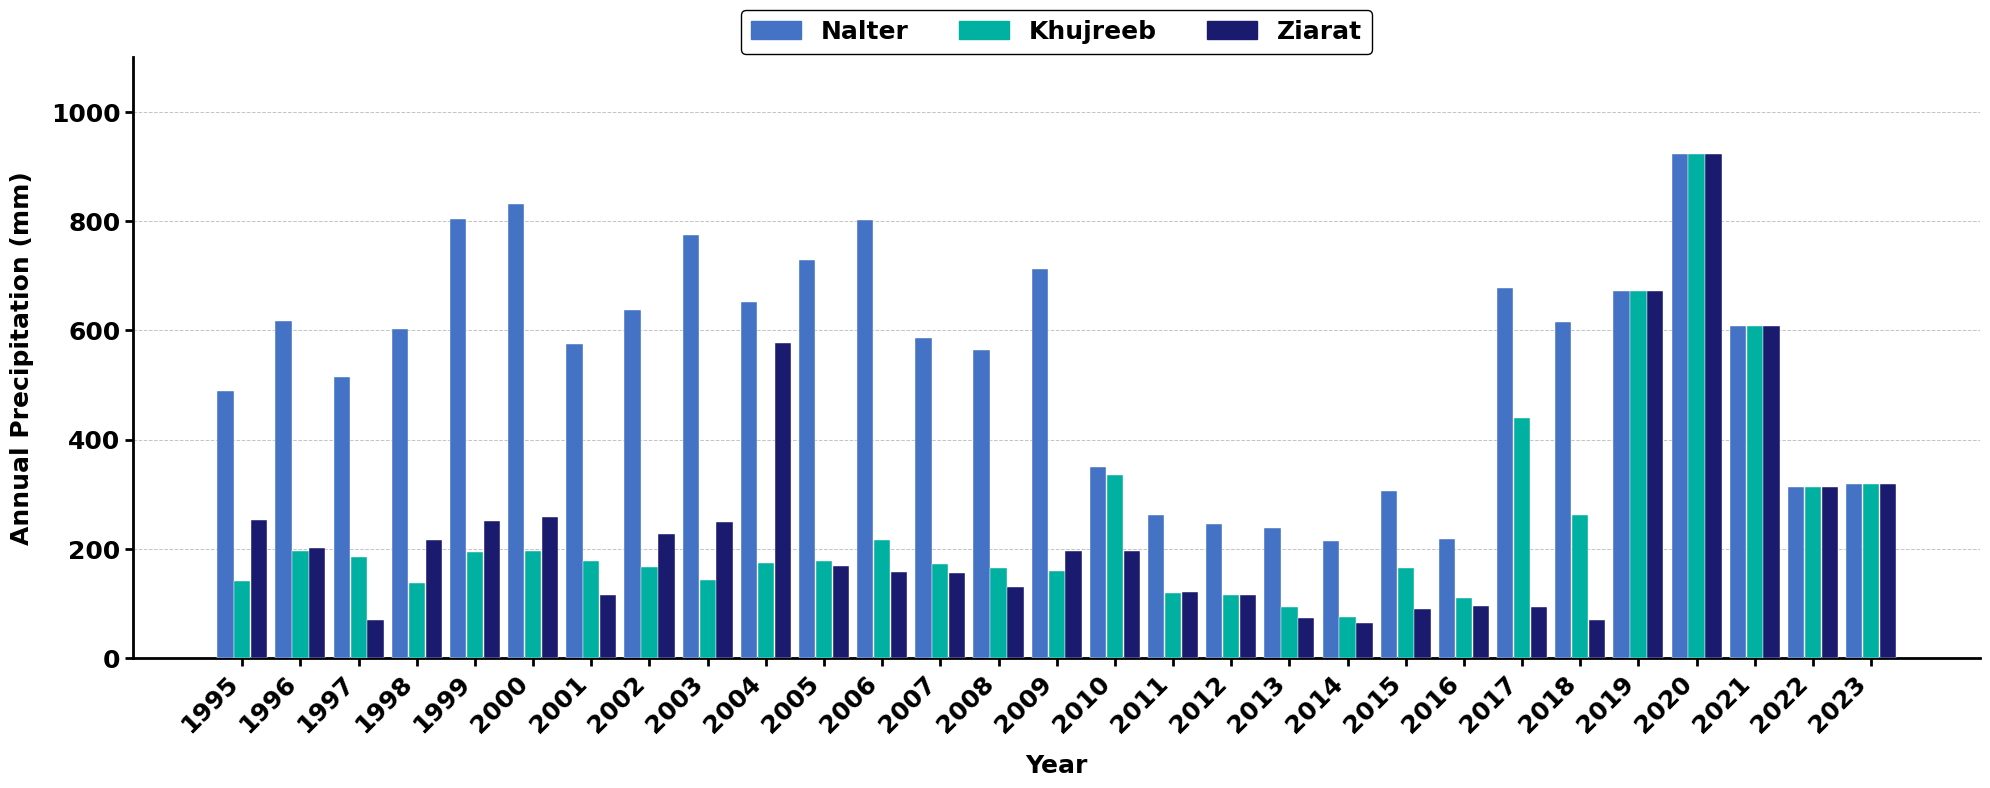


✓ PNG saved at 400 DPI
✓ SVG saved — recommended for Word (Insert > Pictures)


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ============================================================
# LOAD YOUR DATA
# ============================================================
df = pd.read_excel(r"D:\write up\Meteorological data\HUnza River Basin\Precipitation.xlsx")

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Year'] = df['Date'].dt.year
df.columns = df.columns.str.strip()

# ============================================================
# CALCULATE ANNUAL TOTALS
# ============================================================
annual      = df.groupby('Year')[['Nalter', 'Khujreeb', 'Ziarat']].sum()
mean_annual = annual.mean()

# ============================================================
# PLOT SETTINGS
# ============================================================
years     = annual.index.tolist()
n_years   = len(years)
x         = np.arange(n_years)
bar_width = 0.28
gap       = 0.01

# Strong visible colors for Word
colors = {
    'Nalter'  : '#4472C4',   # strong Microsoft Word blue
    'Khujreeb': '#00B0A0',   # strong teal green
    'Ziarat'  : '#1A1A6E',   # very dark navy
}

# ============================================================
# FIGURE — white background for Word
# ============================================================
fig, ax = plt.subplots(figsize=(20, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# --------------------------------------------------------
# DRAW BARS
# --------------------------------------------------------
ax.bar(x - bar_width - gap,
       annual['Nalter'],
       width=bar_width,
       color=colors['Nalter'],
       label='Nalter',
       edgecolor='white',
       linewidth=0.3,
       zorder=3)

ax.bar(x,
       annual['Khujreeb'],
       width=bar_width,
       color=colors['Khujreeb'],
       label='Khujreeb',
       edgecolor='white',
       linewidth=0.3,
       zorder=3)

ax.bar(x + bar_width + gap,
       annual['Ziarat'],
       width=bar_width,
       color=colors['Ziarat'],
       label='Ziarat',
       edgecolor='white',
       linewidth=0.3,
       zorder=3)

# --------------------------------------------------------
# X-AXIS
# --------------------------------------------------------
ax.set_xticks(x)
ax.set_xticklabels(years,
                   rotation=45,
                   ha='right',
                   fontsize=18,
                   fontweight='bold',
                   color='black')

# --------------------------------------------------------
# Y-AXIS
# --------------------------------------------------------
ax.set_yticks(range(0, 1100, 200))
ax.set_yticklabels([str(v) for v in range(0, 1100, 200)],
                   fontsize=18,
                   fontweight='bold',
                   color='black')

# --------------------------------------------------------
# AXIS LABELS
# --------------------------------------------------------
ax.set_ylabel('Annual Precipitation (mm)',
              fontsize=18,
              fontweight='bold',
              color='black',
              labelpad=12)

ax.set_xlabel('Year',
              fontsize=18,
              fontweight='bold',
              color='black',
              labelpad=12)

# --------------------------------------------------------
# TICK PARAMS
# --------------------------------------------------------
ax.tick_params(axis='both',
               which='major',
               width=2,
               length=6,
               colors='black')

ax.set_ylim(0, 1100)

# --------------------------------------------------------
# SPINES — thick black borders for clarity in Word
# --------------------------------------------------------
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_linewidth(2)
ax.spines['bottom'].set_color('black')

# --------------------------------------------------------
# GRIDLINES — subtle but visible
# --------------------------------------------------------
ax.yaxis.grid(True,
              linestyle='--',
              linewidth=0.7,
              color='#AAAAAA',
              alpha=0.7,
              zorder=0)
ax.set_axisbelow(True)

# --------------------------------------------------------
# TITLE
# --------------------------------------------------------

# --------------------------------------------------------
# LEGEND — bold and large, top center
# --------------------------------------------------------
legend_patches = [
    mpatches.Patch(color=colors['Nalter'],   label='Nalter'),
    mpatches.Patch(color=colors['Khujreeb'], label='Khujreeb'),
    mpatches.Patch(color=colors['Ziarat'],   label='Ziarat'),
]
legend = ax.legend(handles=legend_patches,
                   loc='upper center',
                   bbox_to_anchor=(0.5, 1.10),
                   fontsize=18,
                   frameon=True,
                   framealpha=1.0,
                   edgecolor='black',
                   facecolor='white',
                   ncol=3)

for text in legend.get_texts():
    text.set_fontweight('bold')
    text.set_fontsize(18)
    text.set_color('black')

# ============================================================
# SAVE — high DPI for Word clarity
# ============================================================
plt.tight_layout()

# Save as PNG (high DPI)
plt.savefig(
    r'D:\GDM Model\Thesis\Results\precipitation\Annual_Precipitation_Word.png',
    dpi=400,
    bbox_inches='tight',
    facecolor='white'
)

# Save as SVG (best for Word — fully sharp at any size)
plt.savefig(
    r'D:\GDM Model\Thesis\Results\precipitation\Annual_Precipitation_Word.svg',
    format='svg',
    bbox_inches='tight',
    facecolor='white'
)

plt.show()
print("\n✓ PNG saved at 400 DPI")
print("✓ SVG saved — recommended for Word (Insert > Pictures)")